# Binary Classification with a Pretrained Backbone (DenseNet-121)

Transfer learning from an ImageNet-pretrained DenseNet-121 -- the architecture
behind CheXNet. We train a fresh head on the frozen backbone, then fine-tune the
top of the backbone at a low learning rate.

## Setup

In [ ]:
# --- remote/local setup: all logic lives in visualization.colab_bootstrap ---
import os
import sys

try:
    from visualization import colab_bootstrap
except ModuleNotFoundError:
    if "google.colab" in sys.modules and not os.path.exists("ConvolutedComputerVision"):
        !git clone -q https://github.com/samlowe106/ConvolutedComputerVision.git
    for _p in (
        "../src",
        "ConvolutedComputerVision/src",
        "/content/ConvolutedComputerVision/src",
    ):
        if os.path.exists(_p):
            sys.path.insert(0, os.path.abspath(_p))
            break
    from visualization import colab_bootstrap

DATA_ROOT, CKPT_ROOT = colab_bootstrap(
    data_subdir="chest-x-ray-pneumonia",
    dataset_script="chest-x-ray-images-pneumonia/download_data.py",
)

In [1]:
import datetime

import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_recall_curve

notebook_start_time = datetime.datetime.now()

I0000 00:00:1782508377.461889    7388 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782508378.836210    7388 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
test_dir = f"{DATA_ROOT}/test"
train_dir = f"{DATA_ROOT}/train"
validation_dir = f"{DATA_ROOT}/val"

# DenseNet-121 (ImageNet) expects 224x224 RGB; the grayscale X-rays load as 3 equal channels
height, width, channels = 224, 224, 3

batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
)

# validation/test are shuffle=False so labels stay aligned with model.predict
validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
    shuffle=False,
)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

In [3]:
from visualization import reset_keras, show_confusion_matrix, summary_graphics


def get_class_training_weights(train_ds, normalize=True):
    labels, counts = np.unique(
        np.concatenate([y for x, y in train_ds], axis=0), return_counts=True
    )
    total = sum(counts)

    weights = [total / (2 * count) for count in counts]
    max_weight = np.max(weights)

    if normalize:
        return {label: weights[i] / max_weight for i, label in enumerate(labels)}

    return {label: weights[i] for i, label in enumerate(labels)}

In [4]:
class_weight = get_class_training_weights(train_ds=train_ds)

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

Weight for normal class: 1.000
Weight for pneumonia class: 0.348


## Model: DenseNet-121 transfer learning

Instead of learning features from our ~4.4k images, we borrow them from a
DenseNet-121 pretrained on ImageNet (1.3M images). The recipe is two phases:

1. **Freeze** the backbone and train only a fresh classifier head -- fast, and it
   adapts the head to the pretrained features without disturbing them.
2. **Unfreeze** the top of the backbone and continue at a very low learning rate,
   nudging the high-level features toward chest X-rays.

DenseNet-121 at 224x224 is **heavy on CPU** -- expect slow epochs. To iterate
faster, swap the backbone to `MobileNetV2` (see the comment in the model cell).

In [5]:
metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc"),
]


def make_callbacks(filepath):
    # select on val AUC (threshold-free, robust to the class imbalance)
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_auc", mode="max"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=4, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=2
        ),
    ]


epochs = 10

In [6]:
reset_keras()

# DenseNet-121 is the chest-X-ray standard, but heavy on CPU. To iterate faster,
# swap both lines for MobileNetV2 + tf.keras.applications.mobilenet_v2.preprocess_input.
backbone = tf.keras.applications.DenseNet121
preprocess_input = tf.keras.applications.densenet.preprocess_input

base_model = backbone(
    include_top=False, weights="imagenet", input_shape=(height, width, channels)
)
base_model.trainable = False  # phase 1: frozen feature extractor

inputs = tf.keras.Input((height, width, channels), name="input")
# light augmentation (no horizontal flip -- anatomically wrong for chest X-rays)
x = tf.keras.layers.RandomRotation(0.1)(inputs)
x = tf.keras.layers.RandomTranslation(0.1, 0.1)(x)
x = preprocess_input(x)  # DenseNet's expected input normalization
x = base_model(x, training=False)  # training=False keeps BatchNorm in inference mode
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
model_1 = tf.keras.Model(inputs, outputs, name="densenet121_transfer")

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)
model_1.summary()

Model: "densenet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Phase 1: train the head on the frozen backbone

In [ ]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(os.path.join(CKPT_ROOT, "best_model_head.keras")),
)
summary_graphics(history, model_1, test_ds)

## Phase 2: fine-tune the top of the backbone

Unfreeze the backbone and continue at a much lower learning rate. We keep the base
in inference mode for BatchNorm (`training=False` above), so only the conv weights
move -- gently, so we don't wreck the pretrained features.

In [ ]:
base_model.trainable = True

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5),  # low LR for fine-tuning
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

ckpt_path = os.path.join(CKPT_ROOT, "best_model.keras")
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(ckpt_path),
)
best_model = tf.keras.models.load_model(ckpt_path)
summary_graphics(history, best_model, test_ds)

## Tuning the decision threshold

At the default 0.5 cutoff a high-precision/low-recall model produces many false
negatives. We pick the threshold that maximizes F1 on the **validation** set and
apply it to the **test** set.

25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step
Tuned threshold: 0.087  (default is 0.5)

20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step
   default 0.5: accuracy=0.902  recall=0.962  precision=0.891  false negatives=15
   tuned 0.087: accuracy=0.845  recall=0.995  precision=0.803  false negatives=2


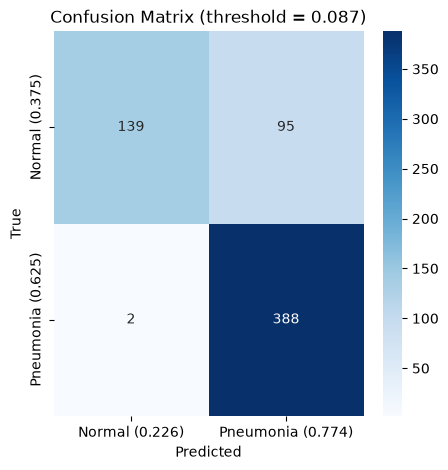

In [9]:
# Choose the decision threshold on the VALIDATION set (never on test), then apply it
# to test. A lower threshold trades a little precision for far fewer false negatives.
val_probs = best_model.predict(validation_ds).ravel()
y_val = np.concatenate([y for _, y in validation_ds], axis=0)

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
threshold = float(thresholds[np.argmax(f1)])
print(f"Tuned threshold: {threshold:.3f}  (default is 0.5)\n")

test_probs = best_model.predict(test_ds).ravel()
y_test = np.concatenate([y for _, y in test_ds], axis=0)

for name, thr in [("default 0.5", 0.5), (f"tuned {threshold:.3f}", threshold)]:
    pred = (test_probs >= thr).astype("int32")
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    print(
        f"{name:>14}: accuracy={np.mean(pred == y_test):.3f}  "
        f"recall={tp / (tp + fn):.3f}  precision={tp / (tp + fp):.3f}  "
        f"false negatives={fn}"
    )

show_confusion_matrix(
    y_test,
    (test_probs >= threshold).astype("int32"),
    title=f"Confusion Matrix (threshold = {threshold:.3f})",
)

In [ ]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} "
    f"(duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-06-27 02:01:07.170126 (duration: 8:48:06.671432)


: 